Importing required libraries to perform necessary data cleaning, EDA, and modeling of the datasets.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.miscmodels.ordinal_model import OrderedModel

Importing Wikipedia's Moody’s sovereign credit rating data as the variable for analysis.

In [2]:
#import wikipedia
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_credit_rating"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)

#for i, table in enumerate(tables):
    #print(i, table.head(), "\n")

/tmp/ipykernel_5356/2122267116.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Selecting the Moody's data table from Wikipedia and creating a copy to begin cleaning the data (i.e., removing the reference column).

In [3]:
moody = tables[2].copy()
moody = moody.drop(columns=["Ref."])
moody.head()

,Country/Territory,Rating,Outlook,Date
0,Angola,B3,Positive,24 October 2023
1,Albania,Ba3,Stable,19 October 2024
2,Argentina,Caa1,Stable,17 July 2025
3,Armenia,Ba3,Stable,22 June 2023
4,Australia,Aaa,Stable,28 June 2022


Converting Moody’s ratings into numeric values in order to apply machine learning and regression models that produce subsequent numeric outcomes. Then mapped the ratings map to the ratings as a new column called Rating Score.

Source: [Moody's Rating Chart](https://www.moodys.com/sites/products/ProductAttachments/contact%20card_gsr%20scale.pdf)

In [4]:
moody_ratings_map = {
    "Aaa":21, "Aa1":20, "Aa2":19, "Aa3":18,
    "A1":17, "A2":16, "A3":15,
    "Baa1":14, "Baa2":13, "Baa3":12,
    "Ba1":11, "Ba2":10, "Ba3":9,
    "B1":8, "B2":7, "B3":6,
    "Caa1":5, "Caa2":4, "Caa3":3,
    "Ca":2, "C":1
}
moody["Rating Score"] = moody["Rating"].map(moody_ratings_map)
moody["Rating Score"] = moody["Rating Score"].astype(int)
moody.head()

,Country/Territory,Rating,Outlook,Date,Rating Score
0,Angola,B3,Positive,24 October 2023,6
1,Albania,Ba3,Stable,19 October 2024,9
2,Argentina,Caa1,Stable,17 July 2025,5
3,Armenia,Ba3,Stable,22 June 2023,9
4,Australia,Aaa,Stable,28 June 2022,21


Creating an investment grade indicator (i.e. if the rating is > Baa3) that helps create a binary variable for whether a country has low default risk. This was done to gain some preliminary understanding of our ratings data.  

In [5]:
#interpreting whether this country is investment grade (i.e. > Baa3)
moody["Investment Grade"] = (moody["Rating Score"] >= 12).astype(int)
moody.head()

,Country/Territory,Rating,Outlook,Date,Rating Score,Investment Grade
0,Angola,B3,Positive,24 October 2023,6,0
1,Albania,Ba3,Stable,19 October 2024,9,0
2,Argentina,Caa1,Stable,17 July 2025,5,0
3,Armenia,Ba3,Stable,22 June 2023,9,0
4,Australia,Aaa,Stable,28 June 2022,21,1


Adding a rating year column in order to merge the Moody rating table with macroeconomic data tables by country and the specific year the ratings were reported. Here, we also standardize Moody's column names that enable easier analysis going forward.

In [6]:
#preparing table to merge with macro indicator csv
moody["Rating Date"] = pd.to_datetime(moody["Date"], errors="coerce")
moody["Rating Year"] = moody["Rating Date"].dt.year
moody = moody.drop(columns=["Date", "Rating Date"])
moody.columns = moody.columns.str.lower()
moody.head()

,country/territory,rating,outlook,rating score,investment grade,rating year
0,Angola,B3,Positive,6,0,2023
1,Albania,Ba3,Stable,9,0,2024
2,Argentina,Caa1,Stable,5,0,2025
3,Armenia,Ba3,Stable,9,0,2023
4,Australia,Aaa,Stable,21,1,2022


# Macro Indicators - World Bank


Import [World Bank](https://databank.worldbank.org/source/world-development-indicators) data that incorporates indicators manually selected via the linked page. This was done to identify possible economic indicators that may help explain differences in sovereign credit ratings.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

world_bank = pd.read_csv("/content/drive/MyDrive/Project 3/worldbank.csv")
world_bank.head()

Mounted at /content/drive


,Country Name,Country Code,Series Name,Series Code,2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,491.337221382603,496.6025042585,510.787063366811,356.496214115892,357.261152798144,413.757894705303,..,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1.18922812944517,3.91160341625552,-2.35110067203466,-20.7388393676343,-6.24017199240269,2.26694373649188,..,..
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,0.626149149168846,2.30237251516833,5.60188791482224,5.13320340824962,13.7121023720064,-4.64470870797774,-6.60118564073725,..
3,Afghanistan,AFG,Current account balance (% of GDP),BN.CAB.XOKA.GD.ZS,-21.5852741164653,-20.1704643881064,-15.7183027911684,..,..,..,..,..
4,Afghanistan,AFG,External debt stocks (% of GNI),DT.DOD.DECT.GN.ZS,14.6424246657516,13.9496520351375,15.1208585304773,24.7857399527695,23.3368489761511,19.8909368152618,..,..


We clean the World Bank table's column names and also rename them to standardize them so it is prepared to be merged with the Moody data frame going forward.

In [8]:
world_bank.columns = world_bank.columns.str.strip().str.lower().str.replace(" ", "_")
world_bank = world_bank.rename(columns={"country_name": "country/territory"})
#world_bank.head()

We reshape the data here so it can be viewed with one row per country per year per indicator. This allows for easier organization before we create the pivot table of the data.

In [9]:
year_cols = [col for col in world_bank.columns if "yr" in col]

world_bank = world_bank.melt(
    id_vars=["country/territory", "series_name"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

We extract the year and convert indicator values to numeric forms here. Then we create a pivot table of the data so each indicator becomes a column. This panel format is created so that we can easily view the statistics of the macroeconomic indicators corresponding to each country.

In [10]:
world_bank["Rating Year"] = world_bank["year"].str.extract(r"(\d{4})").astype(int)
world_bank["value"] = world_bank["value"].replace("..", np.nan)
world_bank["value"] = pd.to_numeric(world_bank["value"], errors="coerce")
world_bank = world_bank.pivot_table(
    index=["country/territory", "Rating Year"],
    columns="series_name",
    values="value",
    aggfunc="first"
).reset_index()
world_bank.columns.name = None
world_bank.head()

,country/territory,Rating Year,Current account balance (% of GDP),External debt stocks (% of GNI),GDP growth (annual %),GDP per capita (current US$),"Inflation, consumer prices (annual %)","Population, total"
0,Afghanistan,2018,-21.585274,14.642425,1.189228,491.337221,0.626149,36743039.0
1,Afghanistan,2019,-20.170464,13.949652,3.911603,496.602504,2.302373,37856121.0
2,Afghanistan,2020,-15.718303,15.120859,-2.351101,510.787063,5.601888,39068979.0
3,Afghanistan,2021,NaN,24.785740,-20.738839,356.496214,5.133203,40000412.0
4,Afghanistan,2022,NaN,23.336849,-6.240172,357.261153,13.712102,40578842.0


We rename the  World Bank variables into clearer names so the table is more clean and easier to read. This also helps reduce the chance of coding errors going forward with everything standardized.

In [11]:
world_bank = world_bank.rename(columns={
    "GDP per capita (current US$)": "gdp_per_capita",
    "GDP growth (annual %)": "gdp_growth",
    "Inflation, consumer prices (annual %)": "inflation",
    "External debt stocks (% of GNI)": "external_debt"
})
world_bank.head()

,country/territory,Rating Year,Current account balance (% of GDP),external_debt,gdp_growth,gdp_per_capita,inflation,"Population, total"
0,Afghanistan,2018,-21.585274,14.642425,1.189228,491.337221,0.626149,36743039.0
1,Afghanistan,2019,-20.170464,13.949652,3.911603,496.602504,2.302373,37856121.0
2,Afghanistan,2020,-15.718303,15.120859,-2.351101,510.787063,5.601888,39068979.0
3,Afghanistan,2021,NaN,24.785740,-20.738839,356.496214,5.133203,40000412.0
4,Afghanistan,2022,NaN,23.336849,-6.240172,357.261153,13.712102,40578842.0


We add 1 year to the World Bank year and standardize the column formatting here. The reason why we need to add a year is because we are comparing sovereign credit rating reporting dates with macroeconomic indicators that are reported at the end of each fiscal year. This also helps us avoid using information that may not have been available when the rating was assigned.

In [12]:
world_bank["Rating Year"] = world_bank["Rating Year"] + 1
moody.columns = (
    moody.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

world_bank.columns = (
    world_bank.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

We merge Moody’s ratings with World Bank indicators by country and rating year, creating a combined dataset that links sovereign credit ratings with macroeconomic variables from the World Bank that can be used to build relevant models.

In [13]:
combined = moody.merge(world_bank,on=["country/territory", "rating_year"],how="inner")
combined.head()

,country/territory,rating,outlook,rating_score,investment_grade,rating_year,current_account_balance_(%_of_gdp),external_debt,gdp_growth,gdp_per_capita,inflation,"population,_total"
0,Angola,B3,Positive,6,0,2023,8.964775,62.711515,4.216003,3682.113151,21.355290,35635029.0
1,Albania,Ba3,Stable,9,0,2024,-1.662862,48.674782,4.015417,9730.869219,4.758346,2414095.0
2,Argentina,Caa1,Stable,5,0,2025,0.893118,39.058345,-1.342931,13969.783660,219.883929,45696159.0
3,Armenia,Ba3,Stable,9,0,2023,0.737867,83.884942,12.600000,6571.974455,8.640911,2969200.0
4,Australia,Aaa,Stable,21,1,2022,2.447298,NaN,2.006948,60758.904440,2.863913,25685412.0


# Macro Indicators - IMF

Import [IMF](https://data.imf.org/en/Data-Explorer?datasetUrn=IMF.RES:WEO(9.0.0)) data that incorporates indicators manually selected via the linked page. This was done to identify possible economic indicators that may help explain differences in sovereign credit ratings.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

imf = pd.read_csv("/content/drive/MyDrive/Project 3/IMF.csv")
imf.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,2018,2019,2020,2021,2022,2023,2024,2025
0,IMF.RES:WEO(9.0.0),ITA.LP.A,OBS_VALUE,Italy,"Population, Persons for countries / Index for ...",Annual,Millions,59.938,59.817,59.641,59.236,59.030,58.997,58.971,58.934
1,IMF.RES:WEO(9.0.0),G119.PCPIPCH.A,OBS_VALUE,G7,"All Items, Consumer price index (CPI), Period ...",Annual,Units,2.080,1.484,0.789,3.319,7.313,4.691,2.651,2.549
2,IMF.RES:WEO(9.0.0),TWN.LP.A,OBS_VALUE,Taiwan Province of China,"Population, Persons for countries / Index for ...",Annual,Millions,23.589,23.603,23.561,23.375,23.265,23.420,23.400,23.299
3,IMF.RES:WEO(9.0.0),BDI.LP.A,OBS_VALUE,Burundi,"Population, Persons for countries / Index for ...",Annual,Millions,11.859,12.255,12.617,12.965,13.321,13.689,14.048,14.469
4,IMF.RES:WEO(9.0.0),MUS.LP.A,OBS_VALUE,Mauritius,"Population, Persons for countries / Index for ...",Annual,Millions,1.257,1.257,1.256,1.256,1.251,1.248,1.245,1.243


We clean the IMF table's column names and also drop the unnecessary column names to standardize the table so it is prepared to be merged with the Moody data frame going forward.

In [15]:
imf.columns = (imf.columns.str.strip().str.lower().str.replace(" ", "_"))

imf = imf.drop(columns={"dataset","series_code","obs_measure","frequency","scale"})
imf.head()

,country,indicator,2018,2019,2020,2021,2022,2023,2024,2025
0,Italy,"Population, Persons for countries / Index for ...",59.938,59.817,59.641,59.236,59.030,58.997,58.971,58.934
1,G7,"All Items, Consumer price index (CPI), Period ...",2.080,1.484,0.789,3.319,7.313,4.691,2.651,2.549
2,Taiwan Province of China,"Population, Persons for countries / Index for ...",23.589,23.603,23.561,23.375,23.265,23.420,23.400,23.299
3,Burundi,"Population, Persons for countries / Index for ...",11.859,12.255,12.617,12.965,13.321,13.689,14.048,14.469
4,Mauritius,"Population, Persons for countries / Index for ...",1.257,1.257,1.256,1.256,1.251,1.248,1.245,1.243


We reshape the data here so it can be viewed with one row per country per year per indicator. This allows for easier organization before we create the pivot table of the data just like we did for the World Bank statistics.

In [16]:
imf_long = imf.melt(
    id_vars=["country", "indicator"],
    var_name="year",
    value_name="value"
)
imf_long["year"] = imf_long["year"].astype(int)
imf_long["value"] = pd.to_numeric(imf_long["value"], errors="coerce")
#imf_long.head()

We pivot the IMF indicators into separate columns, remove the regional aggregates, and rename the indicators. This is so we can keep only country level observations and create the relevant macroeconomic variables for modeling.

In [17]:
imf_panel = imf_long.pivot_table(
    index=["country", "year"],
    columns="indicator",
    values="value",
    aggfunc="first"
).reset_index()

imf_panel = imf_panel[
    ~imf_panel["country"].str.contains("ASEAN|World|Euro area|Advanced|Emerging", na=False)
]

imf_panel = imf_panel.rename(columns={
    "All Items, Consumer price index (CPI), Period average, percent change": "inflation",
    "Current account balance (credit less debit), Percent of GDP": "current_account",
    "External debt, Percent of GDP": "external_debt",
    "Gross domestic product (GDP), Current prices, Per capita, US dollar": "gdp_per_capita",
    "Population, Persons for countries / Index for country groups": "population"
})
imf_panel.columns.name = None
imf_panel.head()

,country,year,inflation,current_account,external_debt,gdp_per_capita,population
16,"Afghanistan, Islamic Republic of",2018,0.626,12.143,NaN,499.799,36.687
17,"Afghanistan, Islamic Republic of",2019,2.302,11.705,NaN,499.762,37.769
18,"Afghanistan, Islamic Republic of",2020,5.607,13.974,NaN,516.664,38.972
19,"Afghanistan, Islamic Republic of",2021,7.762,-0.056,NaN,356.063,40.099
20,"Afghanistan, Islamic Republic of",2022,10.600,-18.532,NaN,357.347,40.579


Similar to the World Bank data, we add a year to our data frame to match the Moody’s dataset. This is so they merge correctly with Moody’s ratings using country and rating year.

In [18]:

imf_panel["Rating Year"] = imf_panel["year"] + 1
imf_panel = imf_panel.drop(columns=["year"])
imf_panel = imf_panel.rename(columns={
    "country": "country/territory",
    "Rating Year": "rating_year"
})

Here, we replace IMF country names with versions that match the Moody’s country names. The first line of the cell was used to identify which country have differing names. This standardization enables a successful merge with Moody's data table.

In [19]:
#set(imf_panel["country"]) - set(moody["country/territory"])
imf_panel["country/territory"] = imf_panel["country/territory"].replace({
    "Afghanistan, Islamic Republic of": "Afghanistan",
    "Egypt, Arab Republic of": "Egypt",
    "Iran, Islamic Republic of": "Iran",
    "Korea, Republic of": "South Korea",
    "Russian Federation": "Russia",
    "Venezuela": "Venezuela",
    "United States": "United States"
})
imf_country_fix = {
    "Armenia, Republic of": "Armenia",
    "Azerbaijan, Republic of": "Azerbaijan",
    "Bahamas, The": "Bahamas",
    "Bahrain, Kingdom of": "Bahrain",
    "Belarus, Republic of": "Belarus",
    "China, People's Republic of": "China",
    "Congo, Democratic Republic of the": "DR Congo",
    "Congo, Republic of": "Congo",
    "Croatia, Republic of": "Croatia",
    "Czech Republic": "Czechia",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Estonia, Republic of": "Estonia",
    "Eswatini, Kingdom of": "Eswatini",
    "Fiji, Republic of": "Fiji",
    "Hong Kong Special Administrative Region, People's Republic of China": "Hong Kong",
    "Kazakhstan, Republic of": "Kazakhstan",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Latvia, Republic of": "Latvia",
    "Lithuania, Republic of": "Lithuania",
    "Macao Special Administrative Region, People's Republic of China": "Macao",
    "Moldova, Republic of": "Moldova",
    "Mozambique, Republic of": "Mozambique",
    "Netherlands, The": "Netherlands",
    "Poland, Republic of": "Poland",
    "Serbia, Republic of": "Serbia",
    "Slovak Republic": "Slovakia",
    "Slovenia, Republic of": "Slovenia",
    "St. Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "Taiwan Province of China": "Taiwan",
    "Tajikistan, Republic of": "Tajikistan",
    "Türkiye, Republic of": "Turkey",
    "Uzbekistan, Republic of": "Uzbekistan",
    "Venezuela, República Bolivariana de": "Venezuela"
}

imf_panel["country/territory"] = imf_panel["country/territory"].replace(imf_country_fix)

We merge Moody’s ratings with the cleaned IMF panel by country and rating year, creating a second combined dataset using IMF indicators as predictors of sovereign credit ratings.

In [20]:
combined_two = moody.merge(imf_panel, on=["country/territory", "rating_year"], how="inner")
combined_two.head()

,country/territory,rating,outlook,rating_score,investment_grade,rating_year,inflation,current_account,external_debt,gdp_per_capita,population
0,Angola,B3,Positive,6,0,2023,21.360,8.452,NaN,3905.445,35.635
1,Albania,Ba3,Stable,9,0,2024,4.780,-1.204,NaN,8594.203,2.750
2,Argentina,Caa1,Stable,5,0,2025,219.885,0.894,NaN,13538.693,47.068
3,Armenia,Ba3,Stable,9,0,2023,8.641,0.738,NaN,6539.113,2.984
4,Australia,Aaa,Stable,21,1,2022,2.841,2.281,NaN,64411.291,25.774


In order to perform modeling that identifies the relation between macroeconomic indicators and Moody's soverign credit ratings, we need to combine all the data together. This is what's done here.

In [21]:
imf_and_world_bank = combined.merge(combined_two, on=[
        "country/territory",
        "rating",
        "outlook",
        "rating_score",
        "investment_grade",
        "rating_year"],
    how="inner",
    suffixes=("_wb", "_imf")
)

imf_and_world_bank.head()

,country/territory,rating,outlook,rating_score,investment_grade,rating_year,current_account_balance_(%_of_gdp),external_debt_wb,gdp_growth,gdp_per_capita_wb,inflation_wb,"population,_total",inflation_imf,current_account,external_debt_imf,gdp_per_capita_imf,population
0,Angola,B3,Positive,6,0,2023,8.964775,62.711515,4.216003,3682.113151,21.355290,35635029.0,21.360,8.452,NaN,3905.445,35.635
1,Albania,Ba3,Stable,9,0,2024,-1.662862,48.674782,4.015417,9730.869219,4.758346,2414095.0,4.780,-1.204,NaN,8594.203,2.750
2,Argentina,Caa1,Stable,5,0,2025,0.893118,39.058345,-1.342931,13969.783660,219.883929,45696159.0,219.885,0.894,NaN,13538.693,47.068
3,Armenia,Ba3,Stable,9,0,2023,0.737867,83.884942,12.600000,6571.974455,8.640911,2969200.0,8.641,0.738,NaN,6539.113,2.984
4,Australia,Aaa,Stable,21,1,2022,2.447298,NaN,2.006948,60758.904440,2.863913,25685412.0,2.841,2.281,NaN,64411.291,25.774


In [22]:
#print("Moody + World Bank:", combined.shape)
#print("Moody + IMF:", combined_two.shape)
#print("Final merged dataset:", final_df.shape)

We create the final working dataset and renames columns so it is more clear. This way it is easier to interpret.

In [23]:
final_df = imf_and_world_bank.copy()

final_df = imf_and_world_bank.rename(columns={
    "country/territory": "country",
    "current_account_balance_(%_of_gdp)": "current_account_wb",
    "gdp_per_capita_wb": "gdp_per_capita_wb",
    "inflation_wb": "inflation_wb",
    "population,_total": "population_wb",
    "inflation_imf": "inflation_imf",
    "current_account": "current_account_imf",
    "external_debt_imf": "external_debt_imf",
    "gdp_per_capita_imf": "gdp_per_capita_imf",
    "population": "population_imf"
})

final_df.head()

,country,rating,outlook,rating_score,investment_grade,rating_year,current_account_wb,external_debt_wb,gdp_growth,gdp_per_capita_wb,inflation_wb,population_wb,inflation_imf,current_account_imf,external_debt_imf,gdp_per_capita_imf,population_imf
0,Angola,B3,Positive,6,0,2023,8.964775,62.711515,4.216003,3682.113151,21.355290,35635029.0,21.360,8.452,NaN,3905.445,35.635
1,Albania,Ba3,Stable,9,0,2024,-1.662862,48.674782,4.015417,9730.869219,4.758346,2414095.0,4.780,-1.204,NaN,8594.203,2.750
2,Argentina,Caa1,Stable,5,0,2025,0.893118,39.058345,-1.342931,13969.783660,219.883929,45696159.0,219.885,0.894,NaN,13538.693,47.068
3,Armenia,Ba3,Stable,9,0,2023,0.737867,83.884942,12.600000,6571.974455,8.640911,2969200.0,8.641,0.738,NaN,6539.113,2.984
4,Australia,Aaa,Stable,21,1,2022,2.447298,NaN,2.006948,60758.904440,2.863913,25685412.0,2.841,2.281,NaN,64411.291,25.774


Here, we choose one version of each macroeconomic variable from either the IMF or World Bank data. This is because some of the variables appear in both datasets, so we only nee to select one consistent source to avoid duplicate predictors in the model.

In [24]:
final_df["inflation"] = final_df["inflation_imf"]
final_df["gdp_per_capita"] = final_df["gdp_per_capita_wb"]
final_df["external_debt"] = final_df["external_debt_wb"]
final_df["current_account"] = final_df["current_account_wb"]
final_df["population"] = final_df["population_wb"]

We specify the necessary variables for analysis here. This is done so that we ensure only relevant coonly the main country, rating, year, and macroeconomic variables needed for analysis.  
**Why:** Narrowing the dataset to relevant columns makes the modeling dataset cleaner and easier to use.

In [25]:
final_df = final_df[["country", "rating", "rating_score", "investment_grade", "rating_year", "gdp_per_capita", "gdp_growth", "inflation",
                     "external_debt", "current_account", "population"]]

In [26]:
final_df.isna().sum()

,0
country,0
rating,0
rating_score,0
investment_grade,0
rating_year,0
gdp_per_capita,0
gdp_growth,0
inflation,0
external_debt,50
current_account,3


In [27]:
model_df = final_df.dropna(subset=[
    "gdp_per_capita",
    "gdp_growth",
    "inflation"
])
#print(model_df.shape)
model_df.head()

,country,rating,rating_score,investment_grade,rating_year,gdp_per_capita,gdp_growth,inflation,external_debt,current_account,population
0,Angola,B3,6,0,2023,3682.113151,4.216003,21.360,62.711515,8.964775,35635029.0
1,Albania,Ba3,9,0,2024,9730.869219,4.015417,4.780,48.674782,-1.662862,2414095.0
2,Argentina,Caa1,5,0,2025,13969.783660,-1.342931,219.885,39.058345,0.893118,45696159.0
3,Armenia,Ba3,9,0,2023,6571.974455,12.600000,8.641,83.884942,0.737867,2969200.0
4,Australia,Aaa,21,1,2022,60758.904440,2.006948,2.841,NaN,2.447298,25685412.0


In [28]:
model_df.describe()

,rating_score,investment_grade,rating_year,gdp_per_capita,gdp_growth,inflation,external_debt,current_account,population
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,62.000000,109.000000,1.120000e+02
mean,11.482143,0.491071,2022.937500,22513.643385,4.479095,10.485036,70.924501,-0.950238,4.202230e+07
std,5.721749,0.502167,0.883087,26117.750095,4.796788,26.219924,63.381996,9.063445,1.422304e+08
min,1.000000,0.000000,2022.000000,578.251664,-28.758584,-0.611000,7.933192,-34.606227,2.823180e+05
25%,6.000000,0.000000,2022.000000,4195.628170,2.805025,2.985750,39.288482,-4.199953,3.639894e+06
50%,11.000000,0.000000,2023.000000,10209.147804,4.357246,4.706000,56.596869,-1.186663,1.041047e+07
75%,16.000000,1.000000,2023.000000,34030.386669,6.511191,8.875750,76.921867,3.069049,3.353226e+07
max,21.000000,1.000000,2025.000000,123719.658916,17.989924,219.885000,379.630336,23.554549,1.425423e+09


In [29]:
model_df["rating"].value_counts()

,count
rating,
Aaa,11
B3,9
Caa1,9
Ba3,8
A3,8
Aa3,7
B1,7
Baa3,7
Baa1,6


In [30]:
model_df.select_dtypes(include="number").corr()

,rating_score,investment_grade,rating_year,gdp_per_capita,gdp_growth,inflation,external_debt,current_account,population
rating_score,1.000000,0.866896,-0.102744,0.786268,0.122691,-0.269888,-0.308888,0.308132,0.015363
investment_grade,0.866896,1.000000,-0.011427,0.631734,0.077353,-0.184821,-0.158404,0.214164,0.091463
rating_year,-0.102744,-0.011427,1.000000,0.031430,-0.242793,0.214505,-0.023080,-0.086397,0.105867
gdp_per_capita,0.786268,0.631734,0.031430,1.000000,-0.017102,-0.120444,-0.145782,0.369548,-0.070405
gdp_growth,0.122691,0.077353,-0.242793,-0.017102,1.000000,-0.202526,-0.057860,-0.014431,0.021344
inflation,-0.269888,-0.184821,0.214505,-0.120444,-0.202526,1.000000,0.308463,-0.199123,-0.004636
external_debt,-0.308888,-0.158404,-0.023080,-0.145782,-0.057860,0.308463,1.000000,-0.604822,-0.174145
current_account,0.308132,0.214164,-0.086397,0.369548,-0.014431,-0.199123,-0.604822,1.000000,-0.016949
population,0.015363,0.091463,0.105867,-0.070405,0.021344,-0.004636,-0.174145,-0.016949,1.000000


In [31]:
import numpy as np

features = [
    "gdp_per_capita",
    "gdp_growth",
    "inflation",
    "external_debt",
    "current_account"
]

ordered_df = model_df[["rating_score"] + features].copy()

# convert ALL to numeric (this is the key fix)
for col in features:
    ordered_df[col] = pd.to_numeric(ordered_df[col], errors="coerce")
ordered_df = ordered_df.replace([np.inf, -np.inf], np.nan)
ordered_df = ordered_df.dropna()
print(ordered_df.isna().sum())     # should all be 0
print(np.isfinite(ordered_df).all())  # should be True
print(ordered_df.dtypes)           # should all be float/int

rating_score       0
gdp_per_capita     0
gdp_growth         0
inflation          0
external_debt      0
current_account    0
dtype: int64
rating_score       True
gdp_per_capita     True
gdp_growth         True
inflation          True
external_debt      True
current_account    True
dtype: bool
rating_score         int64
gdp_per_capita     float64
gdp_growth         float64
inflation          float64
external_debt      float64
current_account    float64
dtype: object


In [32]:
X = ordered_df[features]
y = ordered_df["rating_score"]

model = OrderedModel(y, X, distr="logit")
result = model.fit(method="bfgs")
print(result.summary())

Optimization terminated successfully.
         Current function value: 2.282489
         Iterations: 61
         Function evaluations: 67
         Gradient evaluations: 67
                             OrderedModel Results                             
Dep. Variable:           rating_score   Log-Likelihood:                -139.23
Model:                   OrderedModel   AIC:                             316.5
Method:            Maximum Likelihood   BIC:                             356.6
Date:                Thu, 07 May 2026                                         
Time:                        06:35:10                                         
No. Observations:                  61                                         
Df Residuals:                      42                                         
Df Model:                           5                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

In [33]:
#compare with random forest model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X = ordered_df[features]
y = ordered_df["rating_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))

MAE: 3.6684615384615396


In [34]:
#compare to gradient boost model
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

gb_preds = gb.predict(X_test)

print("Gradient Boost MAE:", mean_absolute_error(y_test, gb_preds))

Gradient Boost MAE: 4.634272507924936


In [35]:
!pip install xgboost

In [36]:
#compare with extreme gradient boost model
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))

XGBoost MAE: 4.128225326538086


In [37]:
print("Random Forest MAE:", mean_absolute_error(y_test, preds))
print("Gradient Boost MAE:", mean_absolute_error(y_test, gb_preds))
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))

Random Forest MAE: 3.6684615384615396
Gradient Boost MAE: 4.634272507924936
XGBoost MAE: 4.128225326538086


Random Forest performed the best, boosting models sich as XGBoost and Gradient boost need more data and overfit on smaller datasets. Random forest averages many trees which reduces variance and makes it less sensitive to noise.

In [38]:
#compare to baseline orbit model
ordered_preds = result.model.predict(result.params, exog=X)

# this returns probabilities → convert to expected value
import numpy as np
ordered_pred_values = np.dot(ordered_preds, np.arange(1, ordered_preds.shape[1] + 1))

from sklearn.metrics import mean_absolute_error
print("Ordered Logit MAE:", mean_absolute_error(y, ordered_pred_values))

Ordered Logit MAE: 2.1228721731970044


Baseline orbit model performed the best and had the lowest MAE value.

This next cell loads the libraries used by every figure cell, fixes a single color palette and Seaborn theme so all charts share a consistent style, and defines three small helpers (clean_axes, label_chart, export) that the figure cells reuse.

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

PALETTE = {"navy": "#1f3b73", "red": "#b22234", "gray": "#4d4d4d", "green": "#2a7a3b"}

def setup_style():
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
    plt.rcParams["axes.titleweight"] = "bold"
    plt.rcParams["savefig.dpi"] = 200
    plt.rcParams["savefig.bbox"] = "tight"

def clean_axes(ax, sides=("top", "right")):
    for s in sides:
        ax.spines[s].set_visible(False)
    return ax

def label_chart(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def export(fig, name, download=True):
    fig.savefig(name)
    if download:
        files.download(name)

setup_style()

We plot the count of country-year observations in each Moody's rating bucket, color-coded as investment-grade (navy) or speculative-grade (red). The chart documents the class imbalance in the modeling sample, shows where the bulk of observations sit on the rating scale, and marks the Baa3/Ba1 boundary that becomes important when interpreting errors in the results section.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

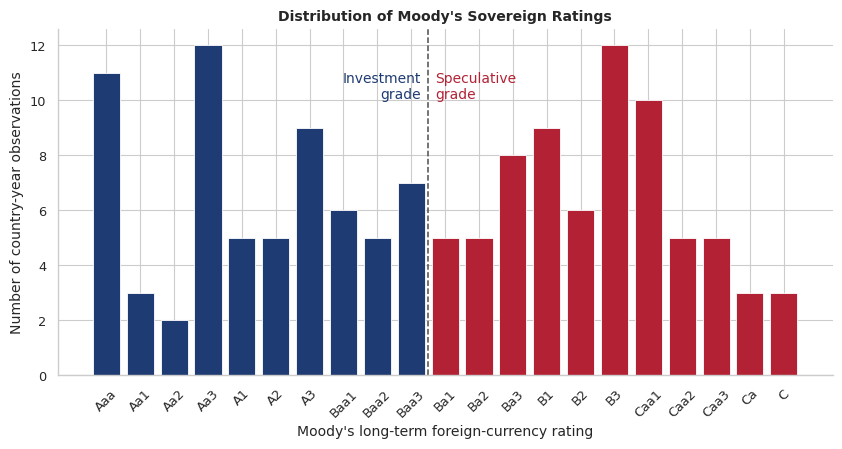

In [40]:
RATING_ORDER = ["Aaa", "Aa1", "Aa2", "Aa3", "A1", "A2", "A3",
                "Baa1", "Baa2", "Baa3", "Ba1", "Ba2", "Ba3",
                "B1", "B2", "B3", "Caa1", "Caa2", "Caa3", "Ca", "C"]
IG_RATINGS = set(RATING_ORDER[:10])
IG_CUTOFF = len(IG_RATINGS) - 0.5

def rating_counts(df, col="rating"):
    return df[col].value_counts().reindex(RATING_ORDER).fillna(0).astype(int)

def bar_colors(labels):
    return [PALETTE["navy"] if r in IG_RATINGS else PALETTE["red"] for r in labels]

def annotate_grades(ax, y):
    ax.text(IG_CUTOFF - 0.2, y, "Investment\ngrade", ha="right", va="top", color=PALETTE["navy"], fontsize=10)
    ax.text(IG_CUTOFF + 0.2, y, "Speculative\ngrade", ha="left", va="top", color=PALETTE["red"], fontsize=10)

def plot_rating_distribution(counts):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(counts.index, counts.values, color=bar_colors(counts.index), edgecolor="white", linewidth=0.6)
    ax.axvline(IG_CUTOFF, color=PALETTE["gray"], linestyle="--", linewidth=1.1)
    annotate_grades(ax, counts.max() * 0.92)
    label_chart(ax, "Distribution of Moody's Sovereign Ratings", "Moody's long-term foreign-currency rating", "Number of country-year observations")
    ax.tick_params(axis="x", rotation=45)
    return clean_axes(ax).figure

counts = rating_counts(moody)
fig = plot_rating_distribution(counts)
export(fig, "fig1_rating_distribution.png")
plt.show()

A boxplot of rating_score grouped by Moody's outlook (Negative, Stable, Positive) with a strip overlay showing the underlying observations and per-group sample sizes. The chart confirms that Stable is the modal outlook and that Positive and Negative outlooks cluster in the middle of the rating spectrum, which is consistent with agencies being unable to assign a directional outlook at the boundaries of the scale.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

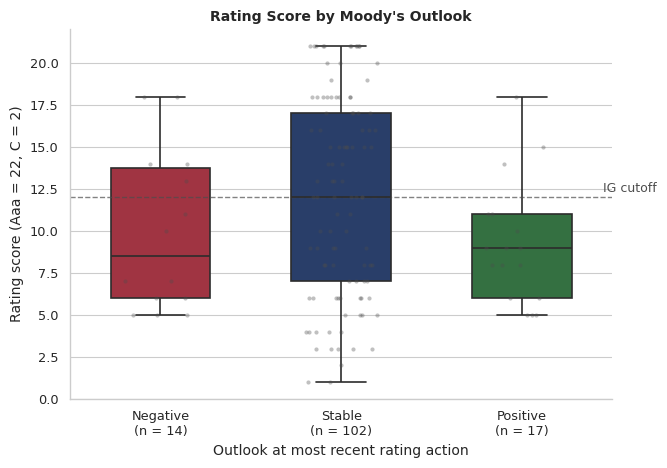

In [41]:
OUTLOOK_ORDER = ["Negative", "Stable", "Positive"]
OUTLOOK_PALETTE = {"Negative": PALETTE["red"], "Stable": PALETTE["navy"], "Positive": PALETTE["green"]}

def filter_outlooks(df, col="outlook", keep=OUTLOOK_ORDER):
    return df[df[col].isin(keep)].copy()

def labeled_outlook_ticks(df, col="outlook"):
    counts = df[col].value_counts()
    return [f"{lab}\n(n = {counts.get(lab, 0)})" for lab in OUTLOOK_ORDER]

def plot_outlook_box(df):
    fig, ax = plt.subplots(figsize=(7, 4.8))
    sns.boxplot(data=df, x="outlook", y="rating_score", order=OUTLOOK_ORDER, hue="outlook", palette=OUTLOOK_PALETTE, legend=False, width=0.55, linewidth=1.2, fliersize=3, ax=ax)
    sns.stripplot(data=df, x="outlook", y="rating_score", order=OUTLOOK_ORDER, color=PALETTE["gray"], alpha=0.35, size=3, jitter=0.2, ax=ax)
    ax.axhline(12, color=PALETTE["gray"], linestyle="--", linewidth=1, alpha=0.7)
    ax.text(2.45, 12.3, "IG cutoff", color=PALETTE["gray"], fontsize=9)
    ax.set_xticks(range(len(OUTLOOK_ORDER)))
    ax.set_xticklabels(labeled_outlook_ticks(df))
    label_chart(ax, "Rating Score by Moody's Outlook", "Outlook at most recent rating action", "Rating score (Aaa = 22, C = 2)")
    return clean_axes(ax).figure

df_outlook = filter_outlooks(moody)
fig = plot_outlook_box(df_outlook)
export(fig, "fig3_outlook_boxplot.png")
plt.show()

Collapsing Moody's 21 alphanumeric notches into 8 broad letter tiers (Aaa through Ca-C) gives a more legible view of the sample's class distribution than the full bar chart. The plot also marks the investment-grade boundary so the reader can see at a glance how the sample splits between IG and speculative-grade sovereigns.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

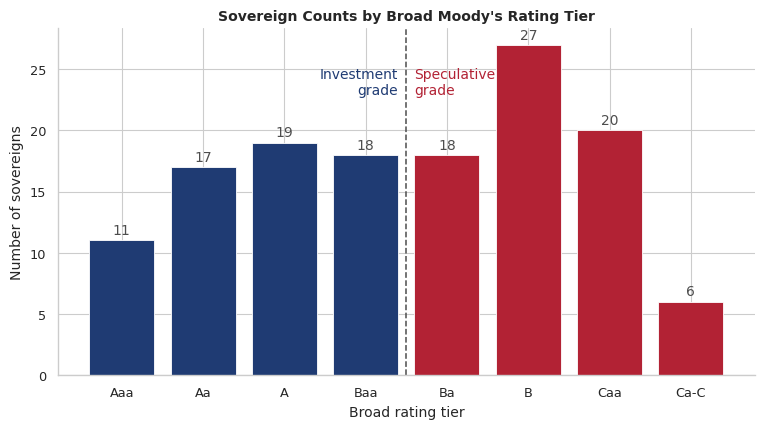

In [42]:
TIER_MAP = {"Aaa": "Aaa", "Aa1": "Aa", "Aa2": "Aa", "Aa3": "Aa",
            "A1": "A", "A2": "A", "A3": "A",
            "Baa1": "Baa", "Baa2": "Baa", "Baa3": "Baa",
            "Ba1": "Ba", "Ba2": "Ba", "Ba3": "Ba",
            "B1": "B", "B2": "B", "B3": "B",
            "Caa1": "Caa", "Caa2": "Caa", "Caa3": "Caa",
            "Ca": "Ca-C", "C": "Ca-C"}
TIER_ORDER = ["Aaa", "Aa", "A", "Baa", "Ba", "B", "Caa", "Ca-C"]
IG_TIERS = {"Aaa", "Aa", "A", "Baa"}

def tier_counts(df, col="rating"):
    return df[col].map(TIER_MAP).value_counts().reindex(TIER_ORDER).fillna(0).astype(int)

def tier_colors(tiers):
    return [PALETTE["navy"] if t in IG_TIERS else PALETTE["red"] for t in tiers]

def annotate_bar_heights(ax, values):
    for bar, v in zip(ax.patches, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, str(int(v)), ha="center", fontsize=10, color=PALETTE["gray"])

def plot_tier_distribution(counts):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(counts.index, counts.values, color=tier_colors(counts.index), edgecolor="white", linewidth=0.6)
    annotate_bar_heights(ax, counts.values)
    ax.axvline(3.5, color=PALETTE["gray"], linestyle="--", linewidth=1.1)
    ax.text(3.4, counts.max() * 0.85, "Investment\ngrade", ha="right", color=PALETTE["navy"], fontsize=10)
    ax.text(3.6, counts.max() * 0.85, "Speculative\ngrade", ha="left", color=PALETTE["red"], fontsize=10)
    label_chart(ax, "Sovereign Counts by Broad Moody's Rating Tier", "Broad rating tier", "Number of sovereigns")
    return clean_axes(ax).figure

counts = tier_counts(moody)
fig = plot_tier_distribution(counts)
export(fig, "fig9_tier_distribution.png")
plt.show()

We benchmark the four candidate models on the same held-out test set and plot their mean absolute error side-by-side. Because Cell 64 reported ordered-logit MAE on the full sample (which is biased downward by training data), this cell first re-predicts the ordered logit on the test set so that all four numbers are computed on identical observations and the comparison is apples-to-apples. The lowest-MAE model is highlighted to make the headline finding immediately legible.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

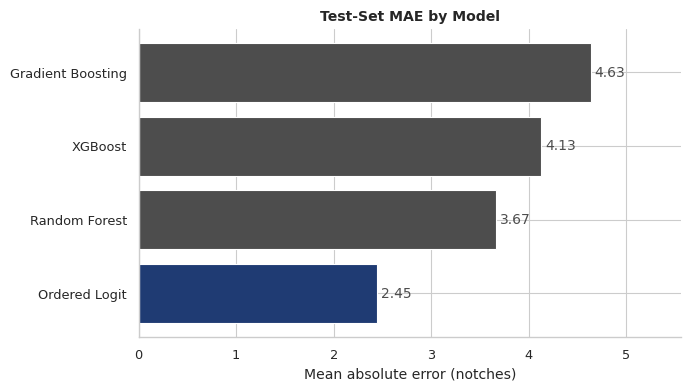

In [43]:
from sklearn.metrics import mean_absolute_error

def ordered_logit_predict(result, X):
    probs = result.model.predict(result.params, exog=X)
    classes = np.arange(1, probs.shape[1] + 1)
    return probs @ classes

def model_mae_dict(y, ol, rf_p, gb_p, xgb_p):
    return {"Ordered Logit": mean_absolute_error(y, ol),
            "Random Forest": mean_absolute_error(y, rf_p),
            "Gradient Boosting": mean_absolute_error(y, gb_p),
            "XGBoost": mean_absolute_error(y, xgb_p)}

def highlight_best(values):
    return [PALETTE["navy"]] + [PALETTE["gray"]] * (len(values) - 1)

def annotate_values(ax, values, fmt="{:.2f}"):
    for bar, v in zip(ax.patches, values):
        ax.text(v + 0.04, bar.get_y() + bar.get_height() / 2, fmt.format(v), va="center", fontsize=10, color=PALETTE["gray"])

def plot_mae(mae_dict):
    s = pd.Series(mae_dict).sort_values()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(s.index, s.values, color=highlight_best(s.values), edgecolor="white")
    annotate_values(ax, s.values)
    label_chart(ax, "Test-Set MAE by Model", "Mean absolute error (notches)", "")
    ax.set_xlim(0, s.max() * 1.20)
    return clean_axes(ax).figure

ol_test_preds = ordered_logit_predict(result, X_test)
mae_dict = model_mae_dict(y_test, ol_test_preds, preds, gb_preds, xgb_preds)
fig = plot_mae(mae_dict)
export(fig, "fig13_mae_comparison.png")
plt.show()

Each point is one test-set sovereign plotted at (actual rating, predicted rating), with the 45-degree line drawn for reference and the investment-grade boundary marked on both axes. Points clustered around the diagonal indicate accurate predictions; systematic deviations such as compression toward the mean at the tails or crossings of the IG boundary are direct evidence of where the model misses, and inform the discussion of which sovereigns are hardest to predict.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

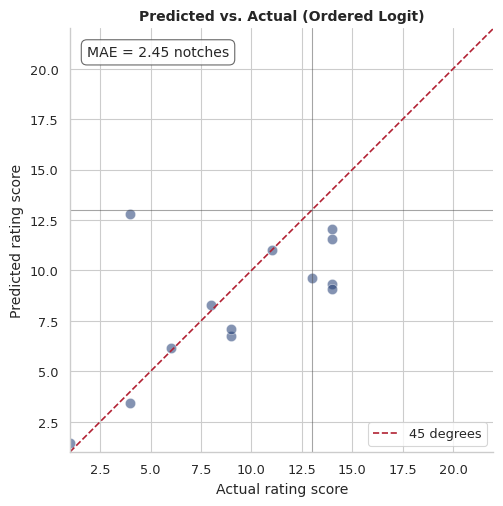

In [44]:
def add_45_line(ax, lo=1, hi=22):
    ax.plot([lo, hi], [lo, hi], color=PALETTE["red"], linestyle="--", linewidth=1.2, label="45 degrees")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

def add_ig_lines(ax, threshold=13):
    ax.axhline(threshold, color=PALETTE["gray"], linewidth=0.8, alpha=0.5)
    ax.axvline(threshold, color=PALETTE["gray"], linewidth=0.8, alpha=0.5)

def add_mae_box(ax, mae):
    box = dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=PALETTE["gray"], alpha=0.85)
    ax.text(0.04, 0.96, f"MAE = {mae:.2f} notches", transform=ax.transAxes, va="top", bbox=box)

def plot_pred_vs_actual(y_true, y_pred, model_name):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(y_true, y_pred, alpha=0.55, color=PALETTE["navy"], edgecolor="white", linewidth=0.5, s=55)
    add_45_line(ax); add_ig_lines(ax)
    add_mae_box(ax, mean_absolute_error(y_true, y_pred))
    ax.set_aspect("equal")
    label_chart(ax, f"Predicted vs. Actual ({model_name})", "Actual rating score", "Predicted rating score")
    ax.legend(loc="lower right", frameon=True)
    return clean_axes(ax).figure

fig = plot_pred_vs_actual(y_test, ol_test_preds, "Ordered Logit")
export(fig, "fig14_pred_vs_actual.png")
plt.show()

A horizontal dumbbell chart, one row per country, plotting both the actual mean rating score (navy circle) and the ordered logit's mean predicted rating score (red diamond) on the same scale. The connecting segment is colored by the direction of the error — green where the model over-predicts, red where it under-predicts, gray for near-perfect fits. Countries are sorted by actual rating so that investment-grade sovereigns sit at the top and speculative sovereigns at the bottom, and the IG cutoff is marked as a dashed vertical line. This view answers the project brief's call to "discuss which countries the model misses and why" by making each country's residual individually visible rather than hidden inside an aggregate MAE.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

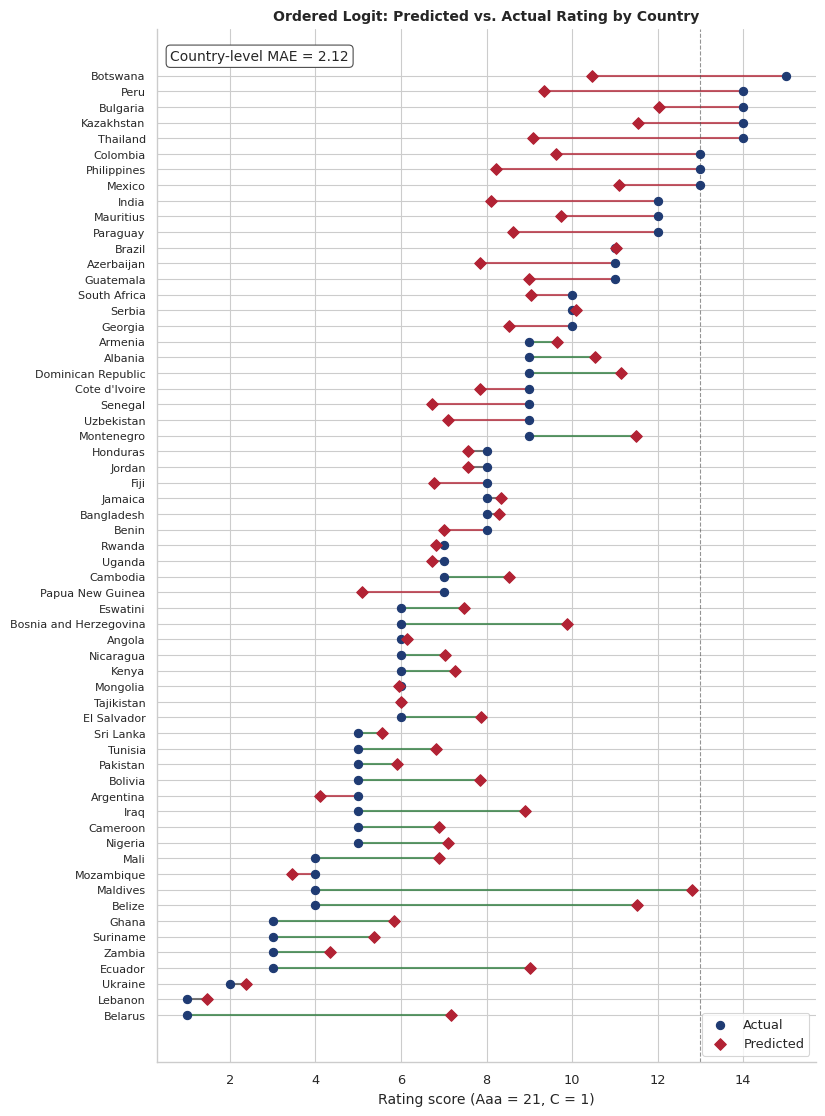

In [45]:
def predict_full(result, X):
    probs = result.model.predict(result.params, exog=X)
    classes = np.arange(1, probs.shape[1] + 1)
    return probs @ classes

def country_predictions(model_df, result, features):
    df = model_df.dropna(subset=features + ["rating_score"]).copy()
    df["predicted"] = predict_full(result, df[features])
    return df.groupby("country").agg(actual=("rating_score", "mean"), predicted=("predicted", "mean")).reset_index()

def add_residual(table):
    out = table.copy()
    out["residual"] = out["predicted"] - out["actual"]
    return out.sort_values("actual", ascending=True).reset_index(drop=True)

def segment_color(residual, tol=0.5):
    if abs(residual) < tol:
        return PALETTE["gray"]
    return PALETTE["green"] if residual > 0 else PALETTE["red"]

def draw_segments(ax, table):
    for i, row in enumerate(table.itertuples()):
        ax.plot([row.actual, row.predicted], [i, i], color=segment_color(row.residual), linewidth=1.5, alpha=0.75)
        ax.scatter(row.actual, i, color=PALETTE["navy"], s=35, zorder=3)
        ax.scatter(row.predicted, i, color=PALETTE["red"], s=35, zorder=3, marker="D")

def add_legend(ax):
    ax.scatter([], [], color=PALETTE["navy"], s=35, label="Actual")
    ax.scatter([], [], color=PALETTE["red"], s=35, marker="D", label="Predicted")
    ax.legend(loc="lower right", frameon=True)

def add_mae_box(ax, table):
    mae = (table["predicted"] - table["actual"]).abs().mean()
    box = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PALETTE["gray"])
    ax.text(0.02, 0.98, f"Country-level MAE = {mae:.2f}", transform=ax.transAxes, va="top", fontsize=10, bbox=box)

def plot_country_dumbbell(table):
    fig, ax = plt.subplots(figsize=(8.5, max(6, len(table) * 0.22)))
    draw_segments(ax, table)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["country"], fontsize=8)
    ax.axvline(13, color=PALETTE["gray"], linestyle="--", linewidth=0.8, alpha=0.6)
    label_chart(ax, "Ordered Logit: Predicted vs. Actual Rating by Country", "Rating score (Aaa = 21, C = 1)", "")
    add_legend(ax); add_mae_box(ax, table)
    return clean_axes(ax).figure

country_table = add_residual(country_predictions(model_df, result, features))
fig = plot_country_dumbbell(country_table)
export(fig, "fig14_country_pred_vs_actual.png")
plt.show()